# 01 — ¿Existe persistencia en el rendimiento de los traders?

**Pregunta:** si rankeamos traders por su desempeño pasado, ¿los mejores siguen superando al resto después?
Si la respuesta es no, ningún TraderScore tiene sentido y hay que replantear el proyecto (ver [ADR-001](../docs/decisions/ADR-001-hyperliquid-first.md)).

**Dos pruebas:**

| | Retroactiva — universo | Retroactiva — **censo** | Forward |
|---|---|---|---|
| Datos | curvas (`portfolio`) de las 300 wallets rastreadas | curvas de **~43k traders del leaderboard**, incluidos ~22k con PnL negativo y ~10k quebrados | snapshots del leaderboard |
| Disponible | ya | conforme avanza el censo (~1 día) | 7 días después del primer snapshot |
| Sesgo | **alto** (universo elegido con el leaderboard de hoy) | **bajo**: solo faltan wallets que nunca llegaron al leaderboard | ninguno de look-ahead |
| Uso | validar el método | **la primera respuesta seria** | confirmación fuera de muestra |

**Cómo leer los resultados** (método en [`analysis/persistence.py`](../analysis/persistence.py), validado con mundos sintéticos en `tests/test_persistence.py`):
- **IC** = correlación de rangos (Spearman) entre la señal y el retorno futuro. 0 = sin información.
- **ic_tstat**: |t| < 2 es indistinguible de ruido.
- **ic_positive**: fracción de periodos con IC > 0. Una señal real debería ganar la mayoría de las veces.
- **random**: un ranking aleatorio sobre los mismos datos. Toda señal debe superarlo con claridad.

Criterio mínimo para decir "hay persistencia": `ic_tstat ≥ 2`, `ic_positive ≥ 0.6` y claramente mejor que `random`, **en el censo**, confirmado después por la prueba forward.

In [1]:
import os
import sys
from pathlib import Path

# Repo root on the path explicitly: on macOS + Python 3.13 the venv's editable-install .pth file
# can carry the "hidden" flag, and Python 3.13 skips hidden .pth files.
sys.path.insert(0, str(Path.cwd().parent))

import duckdb
import matplotlib.pyplot as plt
import polars as pl

from analysis.persistence import leaderboard_persistence, period_returns, retroactive_persistence, summarize

pl.Config.set_tbl_rows(30).set_float_precision(3).set_tbl_hide_dataframe_shape(True)
DATA = Path(os.environ.get("COPY_TRADER_DATA", Path.cwd().parent / "data")).resolve()
P = DATA / "processed" / "hyperliquid"
print("data:", DATA)

def table(name: str) -> str:
    return f"read_parquet('{P / name}/*/*.parquet', union_by_name=true)"

db = duckdb.connect()
equity = db.sql(f"select distinct user, period, time_ms, account_value, pnl from {table('equity_history')}").pl()
leaderboard = db.sql(f"select * from {table('leaderboard')}").pl()
vaults = db.sql(f"select distinct vault_address from {table('vaults')}").pl()["vault_address"] if (P / "vaults").exists() else pl.Series([], dtype=pl.String)

import json
universe = json.loads((DATA / "universe" / "hyperliquid.json").read_text())
cohorts = pl.DataFrame([{"user": u, "cohort": c} for u, w in universe["wallets"].items() for c in w["cohorts"]])

data: /Users/luisencinas/data/copy-trader-backup


## 1. Inventario de datos

In [2]:
snapshots = leaderboard["snapshot_at"].unique().sort()
print(f"wallets en universo:           {len(universe['wallets'])}")
print(f"wallets con curva de capital:  {equity['user'].n_unique()}")
print(f"vaults conocidas (excluidas):  {len(vaults)}")
print(f"snapshots de leaderboard:      {len(snapshots)}  ({snapshots.min()} → {snapshots.max()})")
cohorts.join(equity.select('user').unique(), on='user', how='left', coalesce=True).group_by('cohort').agg(
    tracked=pl.len(), with_history=pl.col('user').is_in(equity['user'].unique().implode()).sum())

wallets en universo:           300
wallets con curva de capital:  47
vaults conocidas (excluidas):  0
snapshots de leaderboard:      1  (2026-10-06T23:22:36.438497+00:00 → 2026-10-06T23:22:36.438497+00:00)


cohort,tracked,with_history
str,u32,u32
"""top_month_roi""",100,11
"""top_alltime_pnl""",100,18
"""random""",100,18


## 2. Prueba retroactiva (sesgada — solo para validar el método)

Retornos de trading en pasos de **2 semanas** (cambio de PnL / capital total al inicio del paso, así los depósitos no cuentan como ganancia).
¿Por qué 2 semanas y capital total? Hyperliquid devuelve ~70-110 puntos por wallet sin importar su antigüedad, así que las historias largas vienen cada ~14 días; y muchos traders guardan su colateral fuera de la cuenta perp. Detalle en `period_returns`.
En cada fecha de formación: señales con las **12 semanas previas**, resultado = retorno de las **4 semanas siguientes**. Las fechas avanzan de 4 en 4 semanas, así que los periodos de resultado no se traslapan.

Señales: `ret` (retorno), `sharpe`, `low_dd` (drawdown menos profundo), `pnl_usd` (ganancia en dólares: lo que ordenan los leaderboards) y `random`.

In [3]:
returns = period_returns(equity).filter(~pl.col("user").is_in(vaults.implode()))
print(f"retornos (wallet × paso de 2 semanas): {returns['ret'].drop_nulls().len()}, wallets: {returns['user'].n_unique()}, "
      f"rango: {returns['end'].min():%Y-%m-%d} → {returns['end'].max():%Y-%m-%d}")

retro = retroactive_persistence(returns, lookback_weeks=12, hold_weeks=4)
retro_summary = summarize(retro)
retro_summary

retornos (wallet × paso de 2 semanas): 1402, wallets: 47, rango: 2023-05-14 → 2026-09-27


signal,periods,wallets_avg,mean_ic,ic_tstat,ic_positive,top_minus_all,top_minus_bottom,top_hit
str,u32,f64,f64,f64,f64,f64,f64,f64
"""random""",27,20.000,-0.034,-0.681,0.519,-0.056,-0.275,0.536
"""sharpe""",27,20.000,-0.061,-0.918,0.370,0.830,0.475,0.431
"""pnl_usd""",27,20.000,-0.083,-1.008,0.407,-0.075,0.013,0.410
"""ret""",27,20.000,-0.108,-1.458,0.259,-0.020,-0.398,0.428
"""low_dd""",27,20.000,-0.118,-1.547,0.407,0.826,0.379,0.443


Solo el grupo **random** del universo (el que no se eligió por desempeño; sigue teniendo sesgo de supervivencia):

In [4]:
random_users = cohorts.filter(pl.col("cohort") == "random")["user"]
summarize(retroactive_persistence(returns, lookback_weeks=12, hold_weeks=4, users=random_users))

┌┐
╞╡
└┘

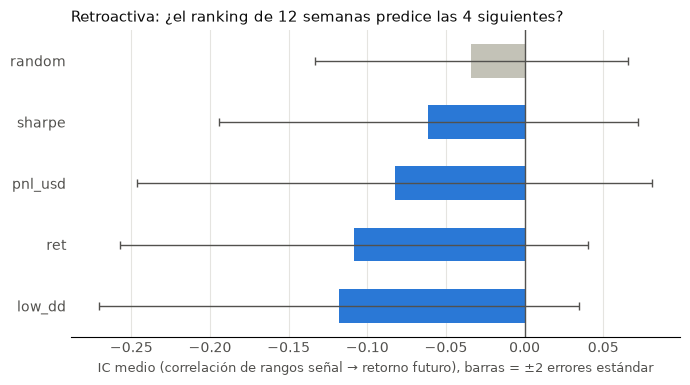

In [5]:
def ic_chart(summary: pl.DataFrame, title: str):
    """Mean IC per signal with a ±2 standard-error band (|t| ≥ 2 means the bar clears zero)."""
    if summary.is_empty():
        print("sin datos suficientes"); return
    s = summary.sort("mean_ic")
    se = (s["mean_ic"] / s["ic_tstat"]).abs().fill_nan(0)
    fig, ax = plt.subplots(figsize=(7, 0.55 * len(s) + 1.2))
    colors = ["#c3c2b7" if n == "random" else "#2a78d6" for n in s["signal"]]
    ax.barh(s["signal"], s["mean_ic"], xerr=2 * se, color=colors, height=0.55,
            error_kw={"elinewidth": 1, "ecolor": "#52514e", "capsize": 3})
    ax.axvline(0, color="#52514e", linewidth=1)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.grid(axis="x", color="#e5e4e0", linewidth=0.8); ax.set_axisbelow(True)
    ax.tick_params(colors="#52514e", length=0)
    ax.set_xlabel("IC medio (correlación de rangos señal → retorno futuro), barras = ±2 errores estándar", color="#52514e", fontsize=9)
    ax.set_title(title, loc="left", color="#0b0b0b", fontsize=11)
    plt.tight_layout(); plt.show()

ic_chart(retro_summary, "Retroactiva: ¿el ranking de 12 semanas predice las 4 siguientes?")

## 3. Censo: ~43k traders, ganadores y perdedores

La prueba seria. El censo se descarga en orden aleatorio, así que un resultado parcial ya es una muestra aleatoria del total.
Dos versiones: todos los traders con ≥ $1k de capital al inicio de cada paso, y solo cuentas "copiables" (≥ $10k).

In [6]:
if (P / "equity_census").exists():
    census_equity = db.sql(f"select distinct user, period, time_ms, account_value, pnl from {table('equity_census')}").pl()
    print(f"traders en el censo procesados: {census_equity['user'].n_unique()}")
    census_returns = period_returns(census_equity)
    census_summary = summarize(retroactive_persistence(census_returns, lookback_weeks=12, hold_weeks=4))
    display(census_summary)
    ic_chart(census_summary, "Censo: ¿el ranking de 12 semanas predice las 4 siguientes?")
else:
    census_equity = None
    print("El censo aún no tiene archivos procesados.")

El censo aún no tiene archivos procesados.


Solo cuentas con ≥ $10k al inicio de cada paso (las que tendría sentido copiar):

In [7]:
if census_equity is not None:
    big = summarize(retroactive_persistence(period_returns(census_equity, min_account=10_000), lookback_weeks=12, hold_weeks=4))
    display(big)
    ic_chart(big, "Censo, cuentas ≥ $10k")

## 4. Prueba forward (confirmación fuera de muestra)

Señal = ROI de la ventana `week` en el snapshot A. Resultado = ROI de la ventana `week` en el snapshot tomado 7 días después, que cubre exactamente los días posteriores a A. Universo: todas las wallets del leaderboard con cuenta ≥ $10k, menos las vaults.
`dropped` = wallets que estaban en A y ya no aparecen en B. No se descartan en silencio.

In [8]:
forward = leaderboard_persistence(leaderboard, horizon_days=7, period="week", exclude=vaults)
if forward.is_empty():
    first = snapshots.min()
    print(f"Aún no hay dos snapshots separados 7 días. Primer snapshot: {first}. "
          "El primer resultado aparece una semana después; se vuelve significativo tras varias semanas.")
else:
    display(summarize(forward))
    ic_chart(summarize(forward), "Forward: ¿el ROI de esta semana predice el de la próxima?")

Aún no hay dos snapshots separados 7 días. Primer snapshot: 2026-10-06T23:22:36.438497+00:00. El primer resultado aparece una semana después; se vuelve significativo tras varias semanas.


## 5. Conclusiones

*(Se completan cuando haya datos suficientes. No interpretar la retroactiva del universo como evidencia: está sesgada.)*

- **Retroactiva (universo):** …
- **Censo:** …
- **Forward:** …
- **Decisión:** …